# MNQ Keltner channel breakout, long-only, 15-minute bars (Tradovate exchange)

Same strategy (`DonchianBreakoutStrategy` fed `Indicators.keltner_channels`'
bands instead of `Indicators.donchian_channels`', per
`keltner_channel_breakout_long_mes_15m.ipynb`'s reuse rationale) applied to
**MNQ** instead of MES.

**Why this pass exists**: Keltner channel breakout was the third structurally
different mechanism (after Donchian channel breakout, SuperTrend ATR-flip) to
confirm the same long-only/15-minute edge on MES, with the strongest MES
TRAIN Sharpe lower bound yet (+0.029). Both prior mechanisms transferred to
MNQ at least as well as MES (MNQ notably *better* on both;
M2K notably weaker on both) -- this pass checks whether Keltner breakout shows
the same per-symbol pattern. `direction=long`, `risk_reward_ratio=2.0`,
`atr_length=10` fixed, same `length`/`atr_mult` grid as the MES pass for
direct comparability.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import DonchianBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MNQ"
SYMBOL = "MNQ/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168271  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:29:59.999000


## Grid search: EMA length x ATR multiplier, direction=long

`risk_reward_ratio=2.0`, `atr_length=10` held fixed.


In [3]:
LENGTH_CANDIDATES = [10, 20, 30, 50, 75]
ATR_MULT_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
ATR_LENGTH = 10
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def run_keltner_breakout_backtest(ohlc_slice: pd.DataFrame, length: int, atr_mult: float, key: str,
                                   direction: StrategyDirection = StrategyDirection.long):
    lower, _middle, upper = Indicators.keltner_channels(ohlc_slice, length=length, atr_length=ATR_LENGTH, atr_mult=atr_mult)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=DonchianBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, upper_key="keltner_upper", lower_key="keltner_lower",
            risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for atr_mult in ATR_MULT_CANDIDATES:
        bt, drawdown_mw = run_keltner_breakout_backtest(ohlc, length, atr_mult, key=f"KC_long_{length}_{atr_mult}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, atr_mult)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "atr_mult": atr_mult,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


length=10 done, 27s elapsed


length=20 done, 63s elapsed


length=30 done, 104s elapsed


length=50 done, 151s elapsed


length=75 done, 189s elapsed



grid done in 189s

    length  atr_mult  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       10       2.0          118.343289      0.754742              -15.1696          607.0             84.3         38.385502       1.304034               0.151565              1.281546         101.294054         2415.14           False
1       10       2.5           87.103895      0.682673              -17.4138          282.0             39.2         38.652482       1.433555               0.159574              1.401713         158.137616         1042.86           False
2       20       1.5          124.049680      0.640169              -23.1072         1209.0            167.9         36.393714       1.212496               0.091811              1.181362          55.008158         4590.04           False
3       10       1.5        

### Heatmaps: Sharpe ratio and net return across (length, atr_mult)


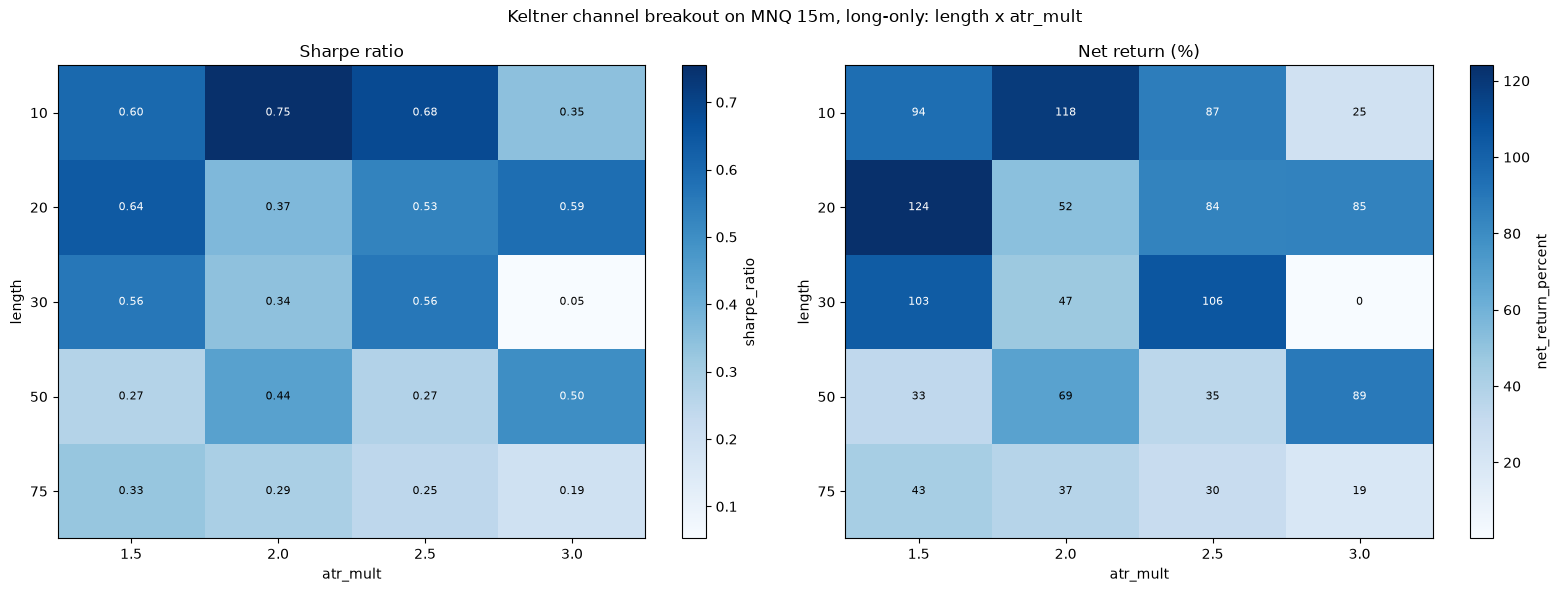

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("atr_mult")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="atr_mult", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="atr_mult", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Keltner channel breakout on {DISPLAY_SYMBOL} 15m, long-only: length x atr_mult")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
grid's best combo -- same report format as every other notebook in this
pipeline.


Best combo: length=10, atr_mult=2.0
Candles Processed: 168270
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MNQ/USD,description
sharpe_ratio,0.7547,1.8771,0.5250,1.1517,-0.0451,1.6945,2.0179,0.3148,0.0828,0.7258,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,1.2192,3.0146,0.8542,1.7924,-0.0699,2.8371,3.4797,0.5363,0.1237,1.0487,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,10.6791,7.9565,13.6762,7.9381,13.9163,7.8460,7.1979,13.2962,9.2588,20.8025,How much the equity curve swings per year. Lower = smoother.
cagr_percent,11.4650,23.5776,9.5099,13.6776,-2.2806,20.7560,23.0175,4.9461,0.4987,20.6027,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.7558,4.5937,0.6678,2.6355,-0.1963,3.0593,5.7181,0.3712,0.0451,0.5814,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,7.8014,2.9099,0.6678,2.6278,-0.1958,3.0501,5.7181,0.3702,0.0238,8.0398,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-15.1696,-5.1326,-14.2417,-5.1898,-11.6153,-6.7846,-4.0254,-13.3238,-11.0583,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,377,91,91,147,240,112,82,83,103,751,How long it took to recover the loss. Shorter is better.
ulcer_index,4.2671,2.0263,4.0864,1.8925,6.2296,1.9861,1.2014,3.3225,3.8577,11.9943,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.9417,-0.7061,-1.2010,-0.6794,-1.3056,-0.7189,-0.6089,-1.0508,-0.9298,-2.0294,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


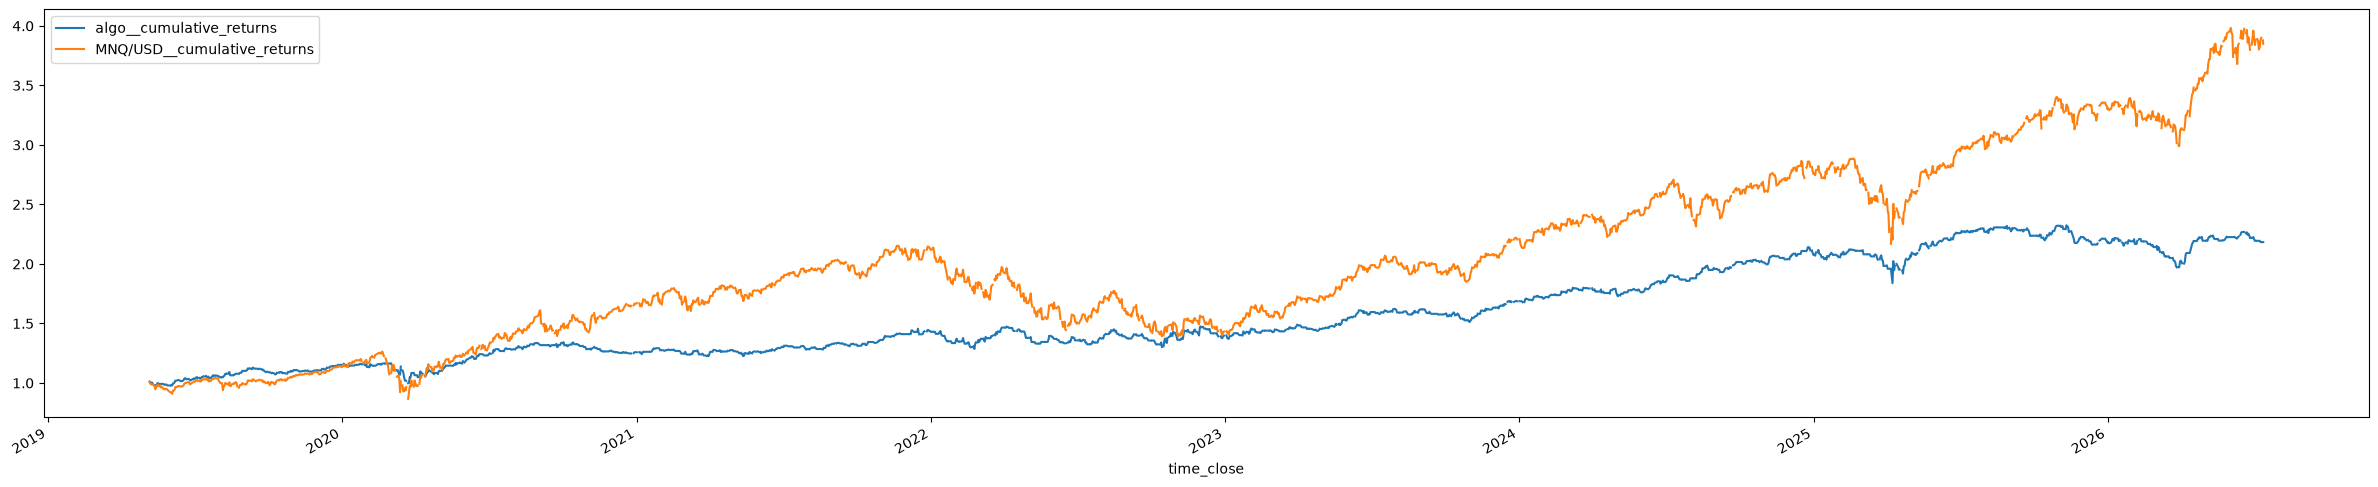

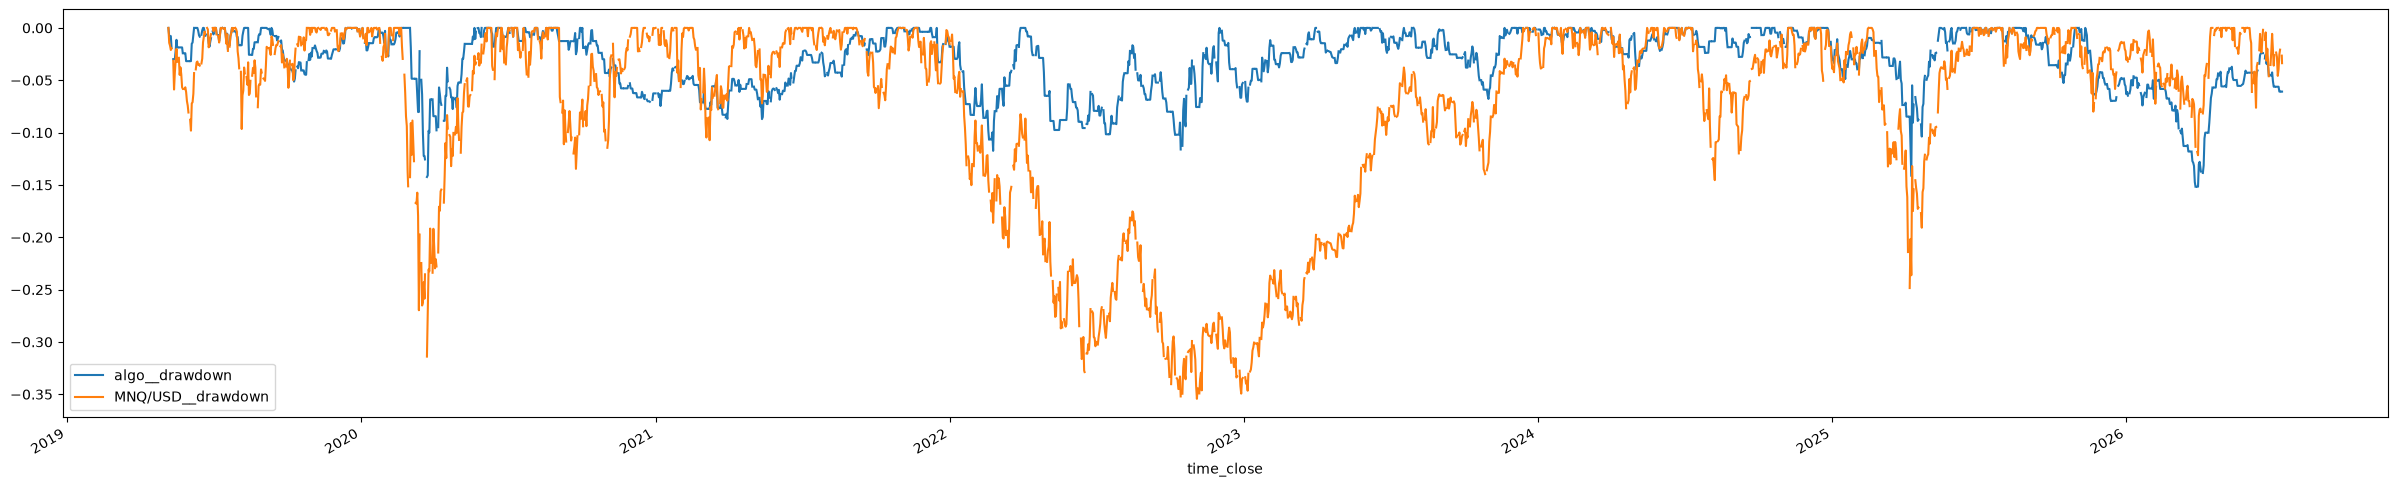

In [5]:
best_length, best_atr_mult = grid_results.iloc[0][["length", "atr_mult"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, atr_mult={best_atr_mult}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_atr_mult)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_keltner_breakout_backtest(ohlc_slice, best_length, float(best_atr_mult), key=f"KC_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-24 11:29:59.999000  (126203 train bars, 42068 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        607         38.385502      0.097476         0.030549        0.754742          118.343289              1.281546         101.294054              -15.1696           False
TRAIN (75%)                 477         38.784067      0.109135         0.033592        0.897146           99.073967              1.339110         106.106409              -14.2417           False
TEST (last 25%, unseen)     129         36.434109      0.055354        -0.089592        0.377235            9.893184              1.165928          45.595152              -15.1514           False


## Findings

**MNQ again produces the strongest result -- this time the strongest TRAIN
lower bound of any (symbol, mechanism) pair tested in this repo.** Best combo
(`length=10, atr_mult=2.0`): FULL net return +118.3%, Sharpe 0.75,
`dollar_profit_factor` 1.28, no drawdown breach.

| window | trades | trade_sharpe | trade_sharpe_lb | dollar_profit_factor |
|---|---|---|---|---|
| TRAIN (75%) | 477 | +0.109 | **+0.0336** | 1.339 |
| TEST (last 25%) | 129 | +0.055 | -0.090 | 1.166 |

TRAIN's `trade_sharpe_lb` (+0.0336) is the highest of any TRAIN result in this
whole research program (MES Keltner: +0.029; MNQ Donchian walk-forward OOS:
+0.0247; MNQ SuperTrend TRAIN+TEST both positive around +0.02). TEST's point
estimate stays positive (+0.055) and `dollar_profit_factor` stays above 1
(1.17) but the lower bound dips negative on the smaller 129-trade sample --
same pattern as every other candidate before walk-forward.

Third mechanism, third confirmation that MNQ is the strongest instrument for
this long-only trend-following edge.


## Walk-forward validation: long-only, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `length` in {5, 10, 15, 20, 30} x `atr_mult` in {1.5, 2.0, 2.5, 3.0}
-- widened down to `length=5` since the full-history best (`length=10`) sat at
the edge of the original grid, the same "still improving at the boundary"
signal that has motivated widening a grid in this pipeline before.
`direction` fixed at `long`, `risk_reward_ratio=2.0` and `atr_length=10` fixed
(same as the full-history pass). Selection uses the same trade-Sharpe-lower-
bound + 3x3-smoothed-plateau methodology as every other walk-forward pass.


In [7]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_LENGTH_GRID = [5, 10, 15, 20, 30]
WF_ATR_MULT_GRID = [1.5, 2.0, 2.5, 3.0]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [8]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for length in WF_LENGTH_GRID:
        for atr_mult in WF_ATR_MULT_GRID:
            bt, _ = run_keltner_breakout_backtest(train_slice, length, atr_mult, key=f"wf{step_i}_train_{length}_{atr_mult}",
                                                   direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"length": length, "atr_mult": atr_mult, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_length, chosen_atr_mult = WF_LENGTH_GRID[0], WF_ATR_MULT_GRID[0]
    else:
        try:
            chosen_length, chosen_atr_mult = pick_plateau(inner_df, "length", "atr_mult", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_length, chosen_atr_mult = best_row["length"], best_row["atr_mult"]

    oos_bt, oos_mw = run_keltner_breakout_backtest(test_slice, int(chosen_length), float(chosen_atr_mult),
                                                    key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_length": int(chosen_length), "chosen_atr_mult": float(chosen_atr_mult),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(length={int(chosen_length)}, atr_mult={chosen_atr_mult}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print(f"\nwalk-forward done in {time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(length=15, atr_mult=3.0) oos_trades=20 oos_net_return=4.9%  (55s elapsed)


step 1: chosen(length=15, atr_mult=3.0) oos_trades=16 oos_net_return=-9.6%  (94s elapsed)


step 2: chosen(length=15, atr_mult=1.5) oos_trades=91 oos_net_return=0.9%  (132s elapsed)


step 3: chosen(length=15, atr_mult=1.5) oos_trades=90 oos_net_return=3.1%  (170s elapsed)


step 4: chosen(length=15, atr_mult=1.5) oos_trades=92 oos_net_return=11.1%  (247s elapsed)


...

step 6: chosen(length=15, atr_mult=1.5) oos_trades=90 oos_net_return=12.4%  (377s elapsed)


step 7: chosen(length=30, atr_mult=3.0) oos_trades=14 oos_net_return=1.5%  (504s elapsed)


step 8: chosen(length=15, atr_mult=1.5) oos_trades=98 oos_net_return=5.4%  (557s elapsed)


step 9: chosen(length=15, atr_mult=1.5) oos_trades=77 oos_net_return=8.2%  (614s elapsed)



walk-forward done in 614s

   step train_start  test_start    test_end  chosen_length  chosen_atr_mult  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05             15              3.0          20             40.000000            -0.119199                4.934267                  1.853292               False
1     1  2019-11-05  2021-11-05  2022-05-05             15              3.0          16             18.750000            -0.996753               -9.550835                  0.287862               False
2     2  2020-05-05  2022-05-05  2022-11-05             15              1.5          91             35.164835            -0.145949                0.860045                  1.028062               False
3     3  2020-11-05  2022-11-05  2023-05-05             15              1.5          90             30.000000            -0.141461                3.082517              

### Parameter stability across steps


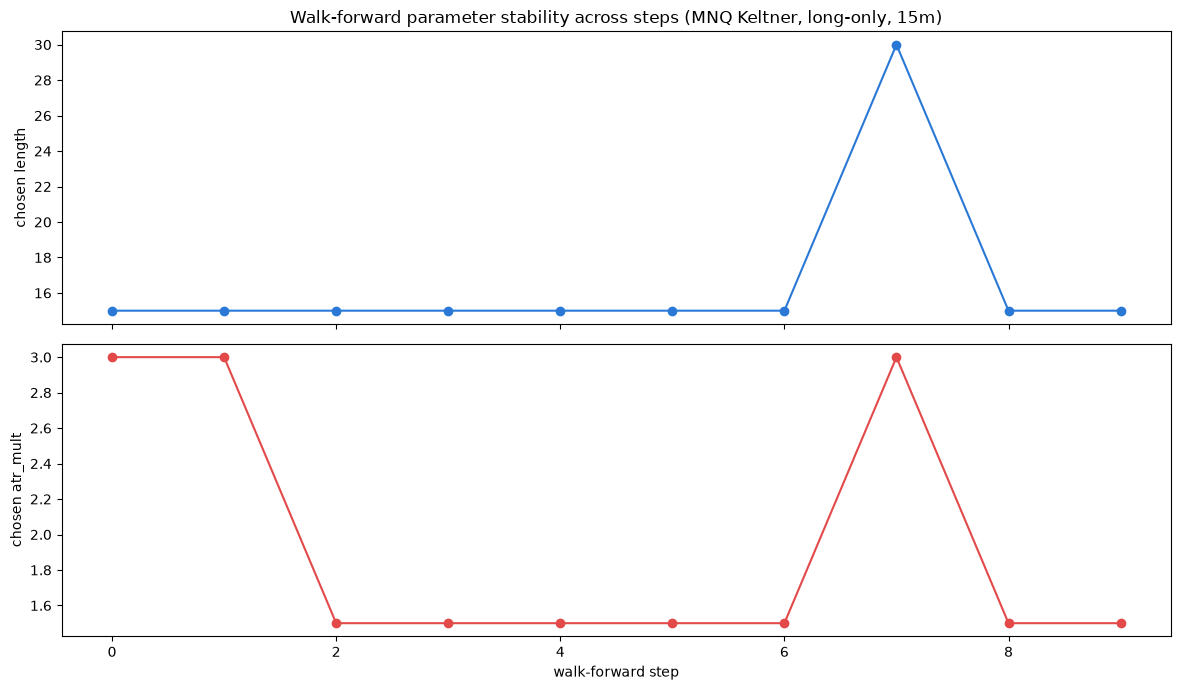

length: unique values chosen = [np.int64(15), np.int64(30)]
atr_mult: unique values chosen = [np.float64(1.5), np.float64(3.0)]


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen length")
axes[0].set_title("Walk-forward parameter stability across steps (MNQ Keltner, long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_atr_mult"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen atr_mult")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"length: unique values chosen = {sorted(wf_results['chosen_length'].unique())}")
print(f"atr_mult: unique values chosen = {sorted(wf_results['chosen_atr_mult'].unique())}")


### The real track record: concatenated out-of-sample trades


In [10]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 664
OOS win rate: 37.35%
OOS trade_sharpe: 0.0593
OOS trade_sharpe_lb: -0.0046
OOS sum of trade pnl (frictionless, %): 52.28%


## Walk-forward conclusion

**The walk-forward does not confirm the strong single-split holdout -- a
useful, humbling result in its own right.**

The 75/25 holdout above showed TRAIN `trade_sharpe_lb=+0.0336`, the best
single-split result in this whole research program. Walk-forward, testing
across 10 independent out-of-sample windows instead of one, lands right back
near zero:

| metric | value |
|---|---|
| OOS trades | 664 |
| OOS win rate | 37.4% |
| OOS `trade_sharpe` (point estimate) | +0.059 |
| OOS `trade_sharpe_lb` | **-0.0046** |
| OOS sum of trade pnl (frictionless) | +52.3% |

8 of 10 steps had positive OOS net return (only step 1, -9.6%, was clearly
bad -- 16 trades, 18.75% win rate, `dollar_profit_factor` 0.29). Most steps
landed in a modest +1% to +12% range. The pooled point estimate is still
positive (+0.059), but one genuinely bad step (step 1) combined with the
overall sample size is enough to pull the lower bound just under zero.

**Parameter stability was good**: `length=15` chosen in 8 of 10 steps,
`atr_mult` mostly 1.5 (only the first two steps, still on thin early history,
chose 3.0). Not the driver of the weaker result -- the selection was
consistent, the out-of-sample performance itself just wasn't quite strong
enough in aggregate.

**Reconciling this with the single-split result**: the single 75/25 split's
TRAIN window happened to land in a stretch where `length=10` (a value not even
reachable by the walk-forward's most-selected `length=15`) performed
unusually well, and that result doesn't generalize as cleanly across the 10
independent walk-forward windows. This is exactly the failure mode
`OPTIMIZATION_RESEARCH_PLAN.md` walk-forward validation exists to catch --
and exactly why a single train/test split was never treated as sufficient
confirmation anywhere else in this pipeline either. `trade_sharpe_lb=-0.0046`
is close enough to MES Donchian's own walk-forward result
(`+0.0032`) that the two are statistically indistinguishable from each other
and from zero -- both are "not disproven, not confirmed," not "MNQ Keltner
is the best strategy in the program" the single-split number alone would have
suggested.
